In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import torch
import pandas as pd
import numpy as np
import seaborn as sn
import re
import argparse
import matplotlib.pyplot as plt
import time
import random 

from model import GBVDataset
from model import BertFineTuner, BertBaseline 
from sklearn.metrics import balanced_accuracy_score

from transformers import AutoTokenizer
from torch.optim import AdamW

import torch
from torch.utils.data import DataLoader

from typing import Dict
from typing import List
from tqdm import tqdm

import json

from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

from torch.optim.lr_scheduler import CosineAnnealingLR
from augmentation import text_augmentation

/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Cached file found: wn-data/downloads/2f7260b24e923d5de63e91dc541d5d4bebab78d1
Skipping own-pt:1.0.0 (OpenWordnet-PT); already added

[nltk_data] Downloading package stopwords to nltk_data/...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
def prepare_datasets(json_path: str): 

    with open(json_path, 'r') as f:
        data = json.load(f)

    train_keys, test_keys = train_test_split(list(data.keys()), test_size=0.1, random_state=42)
    train_keys, val_keys = train_test_split(train_keys, test_size=0.2, random_state=42)

    train_data = {key: data[key] for key in train_keys}
    val_data= {key: data[key] for key in val_keys}
    test_data = {key: data[key] for key in test_keys}
    
    return train_data, val_data, test_data 

In [4]:
train_data, val_data, test_data = prepare_datasets('../ap/files/annotate_filled.json')  

In [5]:
train_data

{'2017-10-20_00058063020038260028': {'processo': ['0005806-30.2003.8.26.0028'],
  'nome_arquivo': '2017-10-20_00058063020038260028',
  'relator': ['costabile_e_solimene'],
  'orgao_julgador': ['9_camara_criminal_extraordinaria'],
  'data_julgamento': ['2017-10-20'],
  'tipo_recurso': ['apelacao_criminal'],
  'colegialidade': ['acordao'],
  'inteiro_teor': ['disponivel'],
  'assunto': ['acao_de_atentado_ao_pudor'],
  'alegou_ap': ['genitor'],
  'acusado_ap': ['genitora_e_sogra'],
  'viol_mulher': ['existencia_de_medida_protetiva'],
  'viol_menor': ['abuso_sexual'],
  'acusado_viol': ['genitor'],
  'resultado_viol': ['nao'],
  'prova_viol': ['in_dubio_pro_reo'],
  'resultado_ap': [''],
  'prova_ap': [''],
  'vies': ['não se ocupou de convencer acerca da demora na revelação das agressões (cerca de um ano), o que se mostrou fora dos padrões da normalidade',
   ' a esposa do réu jamais mencionou qualquer nuance sequer de taras sexuais',
   ' estranho, lacunoso e inconvincente',
   ' nada co

In [6]:
# Definir seed para reprodutibilidade
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed()

In [7]:
MODEL_NAME="neuralmind/bert-base-portuguese-cased"
DATA_PATH='dataset/annotate_filled.json'
MODEL_OUTPUT_DIR="fine-tuned-model"
NUM_CLASSES=2
BATCH_SIZE=32
N_EPOCHS=20
LR=1e-5
#DEVICE='5' # set gpu # 
SEED=42


In [8]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, cache_dir="transformers")
trainset = GBVDataset(train_data,
                    tokenizer,
                    512,
                    data_type='train')

valset = GBVDataset(val_data,
                    tokenizer,
                    512,
                    data_type='val')

testset = GBVDataset(test_data, 
                    tokenizer,
                    512,
                    data_type='test')

trainloader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True)
valloader = DataLoader(valset, batch_size=BATCH_SIZE, shuffle=False)
testloader = DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False) 

model = BertFineTuner(
    model_name=MODEL_NAME,
    num_classes=NUM_CLASSES
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at neuralmind/bert-base-portuguese-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BertConfig {
  "_attn_implementation_autoset": true,
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "classifier_dropout": null,
  "directionality": "bidi",
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "output_past": true,
  "pad_token_id": 0,
  "pooler_fc_size": 768,
  "pooler_num_attention_heads": 12,
  "pooler_num_fc_layers": 3,
  "pooler_size_per_head": 128,
  "pooler_type": "first_token_transform",
  "position_embedding_type": "absolute",
  "torch_dtype": "float32",
  "transformers_version": "4.50.3",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 29794
}



In [7]:
print("GPU disponível:", torch.cuda.is_available())

GPU disponível: True


In [10]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

model = model.to(device)

loss_func = torch.nn.CrossEntropyLoss()
optimizer = AdamW(model.parameters(), lr=LR)
scheduler = CosineAnnealingLR(optimizer, T_max=len(trainset)//BATCH_SIZE*N_EPOCHS, eta_min=1e-8, verbose=True)

/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [11]:
def cm(y_true: list, y_pred: list, phase: str):
    '''
    Builds confusion matrix
    '''
    
    # constant for classes
    classes = (0, 1)

    # confusion matrix
    cf_matrix = confusion_matrix(y_true, y_pred)
    df_cm = pd.DataFrame(cf_matrix/np.sum(cf_matrix), index = [i for i in classes],
                     columns = [i for i in classes])
    plt.figure(figsize = (12,7))
    ax = sn.heatmap(df_cm, annot=True, fmt='.2%', vmin=0, vmax=1)
    ax.set(xlabel="Predicted", ylabel="True")
    filename = 'cm_' + phase + '.png'
    plt.savefig(filename)
    plt.close()

In [11]:
def train_step(input):
    # Train
    model.train()
    model.zero_grad()

    input_ids = input['input_ids'].to(device)
    attention_mask = input['attention_mask'].to(device)
    labels = input['labels'].to(device)
    labels_one_hot = torch.nn.functional.one_hot(labels, num_classes=NUM_CLASSES).to(device)
    labels_one_hot = labels_one_hot.float()

    # Forward
    y_logits = model(input_ids, attention_mask, labels)

    # Loss
    loss = loss_func(y_logits, labels_one_hot.to(device))

    # Backpropagation
    loss.backward()
    optimizer.step()
    
    # Accuracy
    y_hat = torch.argmax(y_logits, dim=1)
    #accuracy = (y_hat == labels).type(torch.float).mean() # not balanced
    y_hat = y_hat.cpu().numpy()
    labels = labels.cpu().numpy()
    balanced_accuracy = balanced_accuracy_score(labels, y_hat)

    return loss.item(), balanced_accuracy, labels, y_hat

def validation_step(input):
    # Validation
    model.eval()

    input_ids = input['input_ids'].to(device)
    attention_mask = input['attention_mask'].to(device)
    labels = input['labels'].to(device)
    labels_one_hot = torch.nn.functional.one_hot(labels, num_classes=NUM_CLASSES).to(device)
    labels_one_hot = labels_one_hot.float()

    with torch.no_grad():
        y_logits = model(input_ids, attention_mask)
        loss = loss_func(y_logits, labels_one_hot)

        # Accuracy
        y_hat = torch.argmax(y_logits, dim=1)
        #accuracy = (y_hat == labels).type(torch.float).mean() # not balanced
        y_hat = y_hat.cpu().numpy()
        labels = labels.cpu().numpy()
        balanced_accuracy = balanced_accuracy_score(labels, y_hat)
                    
    return loss.item(), balanced_accuracy, labels, y_hat


def test_step(input):
            
    input_ids = input['input_ids'].to(device)
    attention_mask = input['attention_mask'].to(device)
    labels = input['labels'].to(device)
    labels_one_hot = torch.nn.functional.one_hot(labels, num_classes=NUM_CLASSES).to(device)
    labels_one_hot = labels_one_hot.float()

    # Forward
    y_logits = model(input_ids, attention_mask, labels)

    # Accuracy
    y_hat = torch.argmax(y_logits, dim=1)
    #accuracy = (y_hat == labels).type(torch.float).mean() # not balanced
    y_hat = y_hat.cpu().numpy()
    labels = labels.cpu().numpy()
    if(1 in y_hat): # if bias was detected in any chunk, all chunks from the same case are assigned the same label
        for i in range(len(y_hat)):
            y_hat[i] = 1
    balanced_accuracy = balanced_accuracy_score(labels, y_hat)

    return balanced_accuracy, labels, y_hat 

In [12]:
start_time = time.time()
    
train_losses = []
train_bal_accs = []
val_losses = []
val_bal_accs = []
current_loss_train = float("inf") 
current_loss_val = float("inf")  

for epoch in tqdm(range(N_EPOCHS),leave=True):

    # Training
    train_loss = []
    train_bal_acc = []
    y_true_train = []
    y_pred_train = []
    
    for input in tqdm(trainloader, desc=f"Training Epoch {epoch}", leave=False):
        optimizer.zero_grad()
        train_loss_batch, train_bal_acc_batch, y_true_batch, y_pred_batch = train_step(input)
        optimizer.step()
        train_loss.append(train_loss_batch)
        train_bal_acc.append(train_bal_acc_batch)
        y_true_train.append(y_true_batch.tolist())
        y_pred_train.append(y_pred_batch.tolist())
    scheduler.step()
    train_loss_epoch = np.average(train_loss)
    train_losses.append(train_loss_epoch)
    train_bal_acc_epoch = np.average(train_bal_acc)
    train_bal_accs.append(train_bal_acc_epoch)
    print(f"Epoch {epoch} - Train Loss: {train_loss_epoch:.4f} - Train Balanced Accuracy: {train_bal_acc_epoch:.4f}")
    y_true_train = [item for sublist in y_true_train for item in sublist] # flattens lists of y_true 
    y_pred_train = [item for sublist in y_pred_train for item in sublist] # flattens lists of y_pred
    if(train_loss_epoch < current_loss_train): # if we are in a better epoch than before, lets build a confusion matrix
        cm(y_true_train, y_pred_train, 'train')
        current_loss_train = train_loss_epoch
    else:
        y_true_train = []
        y_pred_train = []

    
    # Validation
    valid_loss = []
    valid_bal_acc = []
    y_true_val = []
    y_pred_val = []
    for input in tqdm(valloader, desc=f"Validation Epoch {epoch}", leave=False):
        optimizer.zero_grad()
        valid_loss_batch, valid_bal_acc_batch, y_true_batch, y_pred_batch = validation_step(input)
        optimizer.step()
        valid_loss.append(valid_loss_batch)
        valid_bal_acc.append(valid_bal_acc_batch)
        y_true_val.append(y_true_batch.tolist())
        y_pred_val.append(y_pred_batch.tolist())
    scheduler.step(valid_loss_batch)
    valid_loss_epoch = np.average(valid_loss)
    val_losses.append(valid_loss_epoch)
    valid_bal_acc_epoch = np.average(valid_bal_acc)
    val_bal_accs.append(valid_bal_acc_epoch)
    print(f"Epoch {epoch} - Validation Loss: {valid_loss_epoch:.4f} - Validation Balanced Accuracy: {valid_bal_acc_epoch:.4f}")
    y_true_val = [item for sublist in y_true_val for item in sublist] # flattens lists of y_true 
    y_pred_val = [item for sublist in y_pred_val for item in sublist] # flattens lists of y_pred
    if(valid_loss_epoch < current_loss_val): # if we are in a better epoch than before, lets build a confusion matrix
        cm(y_true_val, y_pred_val, 'val')
        current_loss_val = valid_loss_epoch
    else:
        y_true_val = []
        y_pred_val = []

torch.save(model.state_dict(), MODEL_OUTPUT_DIR)
end_time = time.time()
print("Total training time in seconds:", round(end_time-start_time, 4))

  0%|          | 0/20 [00:00<?, ?it/s]/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


Epoch 0 - Train Loss: 0.5875 - Train Balanced Accuracy: 0.5794


/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:243: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)
  5%|▌         | 1/20 [00:09<03:01,  9.53s/it]

Epoch 0 - Validation Loss: 0.4940 - Validation Balanced Accuracy: 0.7500


Epoch 1 - Train Loss: 0.5286 - Train Balanced Accuracy: 0.5069


...

/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:243: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)
 95%|█████████▌| 19/20 [03:06<00:09,  9.84s/it]

Epoch 18 - Validation Loss: 0.3843 - Validation Balanced Accuracy: 0.9048


Epoch 19 - Train Loss: 0.0060 - Train Balanced Accuracy: 1.0000


/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:243: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)
100%|██████████| 20/20 [03:15<00:00,  9.80s/it]


Epoch 19 - Validation Loss: 0.4009 - Validation Balanced Accuracy: 0.9048
Total training time in seconds: 196.4724


In [13]:
start_time = time.time()
test_bal_acc = []
y_true_test = []
y_pred_test = []
for input in tqdm(testloader):
    bal_acc, y_true, y_pred = test_step(input)
    test_bal_acc.append(bal_acc)
    y_true_test.append(y_true.tolist())
    y_pred_test.append(y_pred.tolist())

test_bal_acc_final = np.average(test_bal_acc)
print("Final balanced accuracy for test set: {}".format(test_bal_acc_final))
end_time = time.time()
print("Total testing time in seconds:", round(end_time-start_time, 4))

100%|██████████| 1/1 [00:00<00:00,  2.44it/s]

Final balanced accuracy for test set: 0.5
Total testing time in seconds: 0.4121


### Mukti task

In [8]:
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics import classification_report
import json
import random
import numpy as np
from tqdm import tqdm
import os

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [10]:
# Cell 3: Dataset class
MODEL_NAME = "neuralmind/bert-base-portuguese-cased"
MAX_LEN = 512
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, cache_dir="transformers")

from torch.utils.data import Dataset
from typing import Dict
import torch


class MultiTaskGBVDataset(Dataset):
    """
    Dataset for multi-task classification over judicial bias and target-specific bias.
    """

    def __init__(self,
                 data: Dict,
                 tokenizer,
                 max_length: int = 512,
                 chunk_type: str = "vies_contexto",
                 target_bias_type: str = "abs_mul",
                 data_type: str = None,
                 class_field = "vies"):
        """
        Parameters:
        - data: input data loaded from JSON
        - tokenizer: tokenizer from HuggingFace Transformers
        - max_length: maximum token length
        - chunk_type: which part of the text to use (e.g., 'vies_contexto')
        - target_bias_type: key inside 'vies_alvo' to use as second task label
        - data_type: 'train', 'val' or 'test' (used for augmentation, if needed)
        """
        self.texts = []
        self.labels_a = []  # Task A: bias yes/no
        self.labels_b = []  # Task B: target bias yes/no

        for item in data.values():
            for text in item[chunk_type]:
                self.texts.append(text)

                # Task A: Binary label from "vies"
                label_a = 1 if item["vies"][0] != '' else 0
                self.labels_a.append(label_a)

                # Task B: Binary label from specific bias target
                vies_alvo = item.get("vies_alvo", {})
                print(f"vies alvo {vies_alvo}")
                label_b = 1 if target_bias_type in vies_alvo else 0
                #label_b = 1 if vies_alvo.get(target_bias_type, False) else 0
                print(f"label b {label_b}")
                self.labels_b.append(label_b)

        self.data_type = data_type
        self.max_length = max_length
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.labels_a)

    def encode(self, texts, tokenizer):
        encodes = [
            tokenizer.encode_plus(
                text=text,
                truncation=True,
                padding='max_length',
                max_length=self.max_length,
                add_special_tokens=True
            ) for text in texts
        ]
        return [e['input_ids'] for e in encodes], \
               [e['attention_mask'] for e in encodes]

    def __getitem__(self, idx):
        text = self.texts[idx] if type(self.texts[idx]) is list else [self.texts[idx]]
        label_a = self.labels_a[idx] if type(self.labels_a[idx]) is list else [self.labels_a[idx]]
        label_b = self.labels_b[idx] if type(self.labels_b[idx]) is list else [self.labels_b[idx]]

        # performs data augmentation if in training
        #if self.data_type == "train":          
        #    texts = text_augmentation(texts, label_a)
        token_ids, attention_mask = self.encode(text, self.tokenizer)

        return {
            'input_ids': torch.LongTensor(token_ids).squeeze(),
            'attention_mask': torch.LongTensor(attention_mask).squeeze(),
            'labels_a': torch.LongTensor(label_a).squeeze(),
            'labels_b': torch.LongTensor(label_b).squeeze(),
        }



In [11]:
trainset = MultiTaskGBVDataset(data=train_data, tokenizer=tokenizer)
trainloader = DataLoader(trainset, batch_size=64, shuffle=True)

valset = MultiTaskGBVDataset(data=val_data, tokenizer=tokenizer)
valloader = DataLoader(valset, batch_size=64)



testset = MultiTaskGBVDataset(data=test_data, tokenizer=tokenizer)
testloader = DataLoader(testset, batch_size=64)


vies alvo ['soc', 'abs_mul', 'vitima']
label b 1
vies alvo ['soc', 'abs_mul', 'vitima']
label b 1
vies alvo ['soc', 'abs_mul', 'vitima']
label b 1
vies alvo ['soc', 'abs_mul', 'vitima']
label b 1
vies alvo ['soc', 'abs_mul', 'vitima']
label b 1
vies alvo ['soc', 'abs_mul', 'vitima']
label b 1
vies alvo ['soc', 'abs_mul', 'vitima']
label b 1
vies alvo ['soc', 'abs_mul', 'vitima']
label b 1
vies alvo ['soc', 'abs_mul', 'vitima']
label b 1
vies alvo ['soc', 'abs_mul', 'vitima']
label b 1
vies alvo ['soc', 'abs_mul', 'vitima']
label b 1
vies alvo ['soc', 'abs_mul', 'vitima']
label b 1
vies alvo ['soc', 'abs_mul', 'vitima']
label b 1
vies alvo ['soc', 'abs_mul', 'vitima']
label b 1
vies alvo ['soc', 'abs_mul', 'vitima']
label b 1
vies alvo ['soc', 'abs_mul', 'vitima']
label b 1
vies alvo ['soc', 'abs_mul', 'vitima']
label b 1
vies alvo ['soc', 'abs_mul', 'vitima']
label b 1
vies alvo ['soc', 'abs_mul', 'vitima']
label b 1
vies alvo ['soc', 'abs_mul', 'vitima']
label b 1
vies alvo ['soc', 'a

In [12]:
import torch
from transformers import AutoModelForSequenceClassification

class MultiTaskBertFineTuner(torch.nn.Module):

    def __init__(self, 
                 model_name, 
                 num_classes_task_a,  # Number of classes for Task A (e.g., 2 for binary classification)
                 num_classes_task_b): # Number of classes for Task B (e.g., 2 for binary classification)
        super().__init__()

        # Load the pre-trained BERT model
        self.model = AutoModelForSequenceClassification.from_pretrained(
            model_name,
            num_labels=num_classes_task_a,  # This is for task A initially
            cache_dir='.'
        )

        #print(self.model.config)

        # Freeze the embeddings layer
        for param in self.model.bert.embeddings.parameters():
            param.requires_grad = False

        # Freeze all layers except the last 5 layers
        for layer in self.model.bert.encoder.layer[:-5]: 
            for param in layer.parameters():
                param.requires_grad = False

        # Create separate classification heads for Task A and Task B
        self.classifier_task_a = torch.nn.Linear(self.model.config.hidden_size, num_classes_task_a)
        self.classifier_task_b = torch.nn.Linear(self.model.config.hidden_size, num_classes_task_b)

    def forward(self, input_ids, attention_mask, labels_a=None, labels_b=None):
        '''
        Performs a forward pass through the model for both tasks.
        Returns logits for both tasks.
        '''
        #device = next(self.parameters()).device  # mesmo dispositivo do modelo
        #print(f"device {device}")
        #input_ids = input_ids.to(device)
        #attention_mask = attention_mask.to(device)
        # Get the hidden states from BERT
        output = self.model.bert(input_ids=input_ids, attention_mask=attention_mask)
        
        # Use [CLS] token output (first token) for classification
        cls_output = output.last_hidden_state[:, 0]  # shape: [batch_size, hidden_size]

        # Get logits for both tasks
        logits_a = self.classifier_task_a(cls_output)  # For task A (bias detection)
        logits_b = self.classifier_task_b(cls_output)  # For task B (target bias detection)

        # Return logits for both tasks
        return logits_a, logits_b

    #def to(self, device):
    #    '''Move the model to the given device (CPU or GPU)'''
    #    self.device = device
    #    self = super().to(device)
    #    return self


In [13]:
model_name = "neuralmind/bert-base-portuguese-cased"
num_classes_task_a = 2  # Binary classification for Task A (Bias or No Bias)
num_classes_task_b = 2  # Binary classification for Task B (Bias in target type)


In [ ]:
model = MultiTaskBertFineTuner(model_name, num_classes_task_a, num_classes_task_b)
model.to(device)

In [17]:
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)
criterion = nn.CrossEntropyLoss()

In [ ]:
# Training loop
epochs = 3
model.train()
for epoch in range(epochs):
    total_loss = 0
    for batch in tqdm(trainloader):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels_a = batch['labels_a'].to(device)
        labels_b = batch['labels_b'].to(device)

        logits_a, logits_b = model(input_ids, attention_mask)

        loss_a = criterion(logits_a, labels_a)
        loss_b = criterion(logits_b, labels_b)
        loss = loss_a + loss_b

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    print(f"Epoch {epoch+1} Loss: {total_loss:.4f}")

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:01<?, ?it/s]


OutOfMemoryError: CUDA out of memory. Tried to allocate 2.00 MiB. GPU 0 has a total capacity of 7.75 GiB of which 1.75 MiB is free. Including non-PyTorch memory, this process has 7.74 GiB memory in use. Of the allocated memory 7.55 GiB is allocated by PyTorch, and 75.90 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

: 

In [84]:
from sklearn.metrics import classification_report

In [85]:
# Evaluation
model.eval()
all_preds_a, all_labels_a = [], []
all_preds_b, all_labels_b = [], []

with torch.no_grad():
    for batch in testloader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels_a = batch['labels_a'].to(device)
        labels_b = batch['labels_b'].to(device)

        logits_a, logits_b = model(input_ids, attention_mask)
        preds_a = torch.argmax(logits_a, dim=1)
        preds_b = torch.argmax(logits_b, dim=1)

        all_preds_a.extend(preds_a.cpu().numpy())
        all_labels_a.extend(labels_a.cpu().numpy())
        all_preds_b.extend(preds_b.cpu().numpy())
        all_labels_b.extend(labels_b.cpu().numpy())

print("Task A - vies")
print(classification_report(all_labels_a, all_preds_a))
print("Task B - vies_alvo['abs_mul']")
print(classification_report(all_labels_b, all_preds_b))

Task A - vies
              precision    recall  f1-score   support

           0       1.00      0.83      0.91         6
           1       0.90      1.00      0.95         9

    accuracy                           0.93        15
   macro avg       0.95      0.92      0.93        15
weighted avg       0.94      0.93      0.93        15

Task B - vies_alvo['abs_mul']
              precision    recall  f1-score   support

           0       0.60      1.00      0.75         9
           1       0.00      0.00      0.00         6

    accuracy                           0.60        15
   macro avg       0.30      0.50      0.38        15
weighted avg       0.36      0.60      0.45        15



/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average,

## MOO

In [14]:
from machinemoo import moo, get_objectives, MooScalarization
from machinemoo.analysis.metrics import compute_hypervolume_progress
from machinemoo.analysis.visualization import plot_pareto, plot_multiple_hypervolumes, plot_hypervolume
from machinemoo.scalarization.two_objs_law_gender import Scalarization

In [15]:
# Definir seed para reprodutibilidade
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed()

In [16]:
opt_params = {
    'node_time_limit': 2,
    'target_size': 50,
    'target_gap': 0,
    'node_gap': 0.05,
    'norm': False
}
results = {}

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at neuralmind/bert-base-portuguese-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
15:39:45 | DEBUG | machinemoo | Filtered parameters for Mola: {'node_time_limit': 2, 'target_size': 50, 'target_gap': 0, 'node_gap': 0.05, 'norm': False}
15:39:45 | DEBUG | machinemoo | Finding 1th individual minimum


device: cuda
available: True


Evaluating: 100%|██████████| 3/3 [00:04<00:00,  1.50s/it]
15:40:03 | DEBUG | machinemoo | Finding 2th individual minimum


device: cuda
available: True


Evaluating: 100%|██████████| 3/3 [00:04<00:00,  1.52s/it]
15:40:21 | DEBUG | machinemoo | Calculated weights: [1.35160148e-07 9.99999865e-01]
15:40:21 | DEBUG | machinemoo | Importance: -8.23735096250631e-09
15:40:21 | DEBUG | machinemoo | Global lower bound (y*): [0.67264837 0.56732817]
15:40:21 | DEBUG | machinemoo | Iteration 1
15:40:21 | DEBUG | machinemoo | Solutions list: [array([0.71272967, 0.59910258]), array([0.67264837, 0.56732817])]


...

new solution added [0.06469913 0.0460845 ]
device: cuda
available: True


Evaluating: 100%|██████████| 3/3 [00:04<00:00,  1.56s/it]
15:55:27 | DEBUG | machinemoo | Calculated weights: [0.46441714 0.53558286]
15:55:27 | DEBUG | machinemoo | Importance: 0.0024037398430918483
15:55:27 | DEBUG | machinemoo | Global lower bound (y*): [0.04983883 0.0460845 ]
15:55:27 | DEBUG | machinemoo | Iteration 50
15:55:27 | DEBUG | machinemoo | Solutions list: [array([0.05586925, 0.0555303 ]), array([0.06469913, 0.0460845 ]), array([0.05281124, 0.05639279]), array([0.05196182, 0.06458416]), array([0.05114921, 0.07470503]), array([0.06003371, 0.05458735]), array([0.05022479, 0.07535473]), array([0.04983883, 0.08159873])]


new solution added [0.05586925 0.0555303 ]
device: cuda
available: True


Evaluating: 100%|██████████| 3/3 [00:04<00:00,  1.57s/it]
15:55:46 | DEBUG | machinemoo | Calculated weights: [0.86353638 0.13646362]
15:55:46 | DEBUG | machinemoo | Importance: 0.0008955083151058543
15:55:46 | DEBUG | machinemoo | Global lower bound (y*): [0.04983883 0.0460845 ]
15:55:46 | DEBUG | machinemoo | Iteration 51
15:55:46 | DEBUG | machinemoo | Solutions list: [array([0.05657104, 0.04688888]), array([0.05586925, 0.0555303 ]), array([0.06469913, 0.0460845 ]), array([0.05281124, 0.05639279]), array([0.05196182, 0.06458416]), array([0.05114921, 0.07470503]), array([0.05022479, 0.07535473]), array([0.04983883, 0.08159873])]


new solution added [0.05657104 0.04688888]
solution dominated [0.06003371 0.05458735]


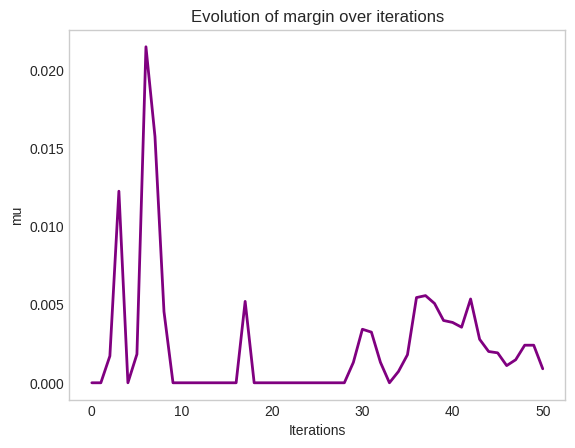

15:55:46 | INFO | machinemoo | Fit runtime: 960.29 seconds


In [17]:
method = 'mola'
w_scalar = Scalarization(train_dataloader=trainloader, device=device, model_name=model_name)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
#hypervolume_values = compute_hypervolume_progress(objs)
hypervolume_values = moopt.get_hypervolumes()
results[method] = {
                "moopt": moopt,
                "objectives": objs,
                "models": moopt.get_models() if hasattr(moopt, "get_models") else None,
                "hypervolume": hypervolume_values
            }

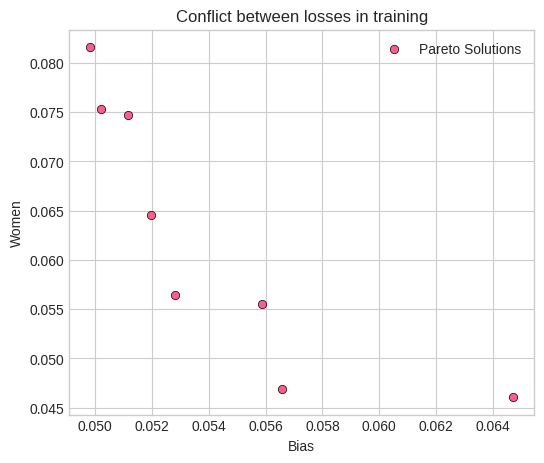

In [18]:
title="Conflict between losses in training"
plot_pareto(objectives=objs, 
               labels=("Bias", "Women"), 
               title=title,
               #point = equal.objs,
               color="#FF5C8D"
               )

In [ ]:
def extract_bert_embeddings(dataset, tokenizer_name="bert-base-uncased", max_length=128, batch_size=32, device="cuda"):
    tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)
    model = AutoModel.from_pretrained(tokenizer_name).to(device)
    model.eval()

    texts = [" ".join(d["post_tokens"]) for d in dataset]

    embeddings = []
    with torch.no_grad():
        for i in tqdm(range(0, len(texts), batch_size)):
            batch_texts = texts[i:i+batch_size]
            encoding = tokenizer(
                batch_texts,
                padding=True,
                truncation=True,
                max_length=max_length,
                return_tensors="pt"
            ).to(device)

            outputs = model(**encoding)
            cls_embeddings = outputs.last_hidden_state[:, 0, :]  # CLS token
            embeddings.append(cls_embeddings.cpu())

    return torch.cat(embeddings, dim=0)  # Shape: (N, hidden_size)

from sklearn.decomposition import PCA

def apply_pca_and_save(embeddings: torch.Tensor, n_components=50, output_path="embeddings_pca.npy"):
    pca = PCA(n_components=n_components)
    reduced = pca.fit_transform(embeddings.numpy())
    np.save(output_path, reduced)
    return reduced

from collections import Counter
from torch.utils.data import Dataset

class PCAEmbeddingsDataset(Dataset):
    def __init__(self, pca_embeddings: npt.NDArray[np.float64], raw_dataset):
        self.embeddings = torch.tensor(pca_embeddings, dtype=torch.float)
        self.raw_dataset = raw_dataset
        

    def __len__(self):
        return len(self.embeddings)

    def __getitem__(self, idx):
        data = self.raw_dataset[idx]

        labels = data["annotators"]["label"]
        majority_label = Counter(labels).most_common(1)[0][0]
        label_hate = 0 if majority_label == 1 else 1

        label_hate = 0 if majority_label == 1 else 1

        # Criar rótulo para discurso de ódio contra gênero (exemplo: "women")
        target_groups = data["annotators"]["target"]
        #label_target = 1 if len(target_groups) > 0 else 0
        hate_women = 0
        hate_homosexual = 0
        hate_indigenous = 0
       
        for i in range(len(target_groups)):
            #print(target_groups[i])
            if label_hate == 1:
                if ('Women' in target_groups[i]):
                    hate_women = 1
                if ('Homosexual' in target_groups[i]):
                    hate_homosexual = 1
                if ('Indigenous' in target_groups[i]):
                    hate_indigenous = 1

        return {
            "embedding": self.embeddings[idx],
            "label": torch.tensor(label_hate, dtype=torch.long),
            "women": torch.tensor(hate_women, dtype=torch.long),
            "homosexual": torch.tensor(hate_homosexual, dtype=torch.long),
            "indigenous": torch.tensor(hate_indigenous, dtype=torch.long),
        }

# Suponha que você tenha carregado seu dataset JSON como `raw_dataset`

# embeddings = extract_bert_embeddings(dataset["train"])
# pca_embeddings = apply_pca_and_save(embeddings, n_components=50, output_path="embeddings_pca.npy")
# #
# ## Agora use para treinar seu modelo
# dataset_pca = PCAEmbeddingsDataset(pca_embeddings, dataset["train"])
# train_dataloader = DataLoader(dataset_pca, batch_size=64, shuffle=True)


In [19]:
method = 'random_weights'
w_scalar = Scalarization(train_dataloader=trainloader, device=device, model_name=model_name)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = compute_hypervolume_progress(objs)
results[method] = {
                "moopt": moopt,
                "objectives": objs,
                "models": moopt.get_models() if hasattr(moopt, "get_models") else None,
                "hypervolume": hypervolume_values
            }

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at neuralmind/bert-base-portuguese-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
15:56:45 | WARNING | machinemoo | Ignored parameters for random_weights: {'nodeTimeLimit', 'targetGap', 'nodeGap'}
15:56:45 | DEBUG | machinemoo | Filtered parameters for random_weights: {'targetSize': 50, 'norm': False}
15:56:45 | DEBUG | machinemoo.moo.random_weights | Finding 1th individual minima


device: cuda
available: True


Evaluating: 100%|██████████| 3/3 [00:04<00:00,  1.50s/it]
15:57:02 | DEBUG | machinemoo.moo.random_weights | Finding 2th individual minima


device: cuda
available: True


Evaluating: 100%|██████████| 3/3 [00:04<00:00,  1.53s/it]


...

Evaluating: 100%|██████████| 3/3 [00:04<00:00,  1.56s/it]
16:11:32 | DEBUG | machinemoo.moo.random_weights | 48th solution


device: cuda
available: True


Evaluating: 100%|██████████| 3/3 [00:04<00:00,  1.57s/it]
16:11:51 | DEBUG | machinemoo.moo.random_weights | 49th solution


device: cuda
available: True


Evaluating: 100%|██████████| 3/3 [00:04<00:00,  1.57s/it]
16:12:10 | DEBUG | machinemoo.moo.random_weights | 50th solution


In [ ]:
from machinemoo.tests.experiments.run import run_experiments

16:12:10 | WARNING | machinemoo | [Methods have different numbers of solutions: {8, 50}


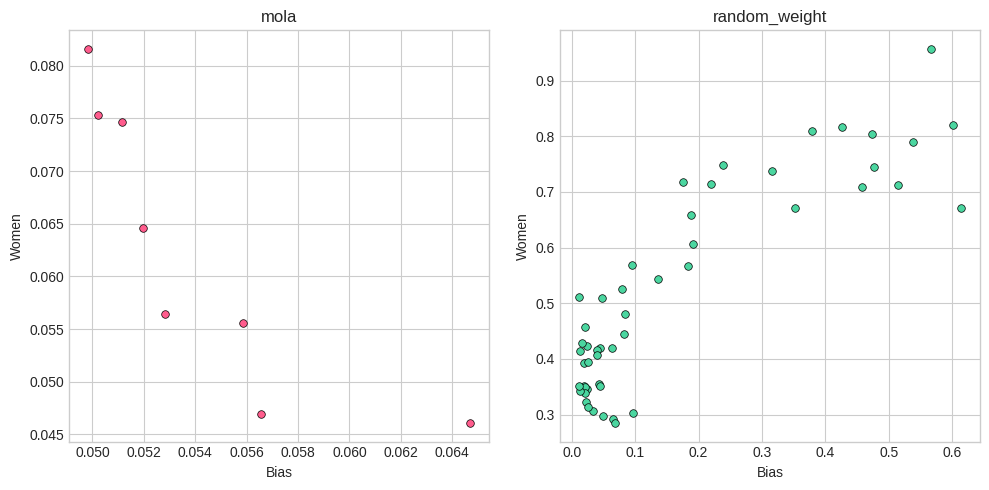

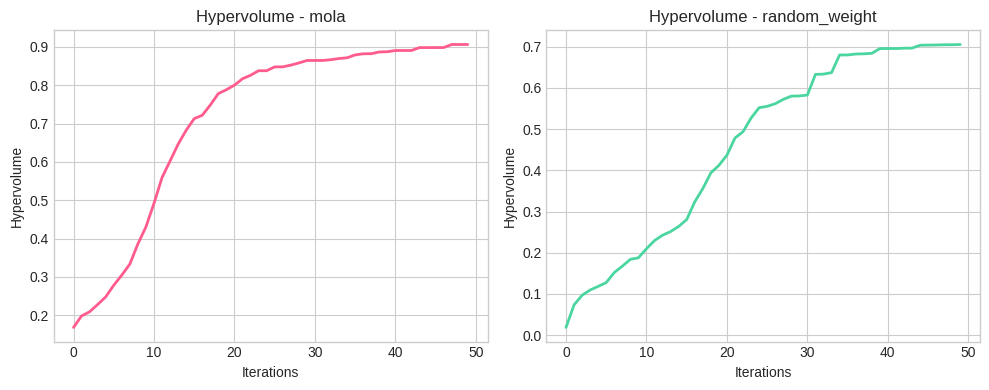

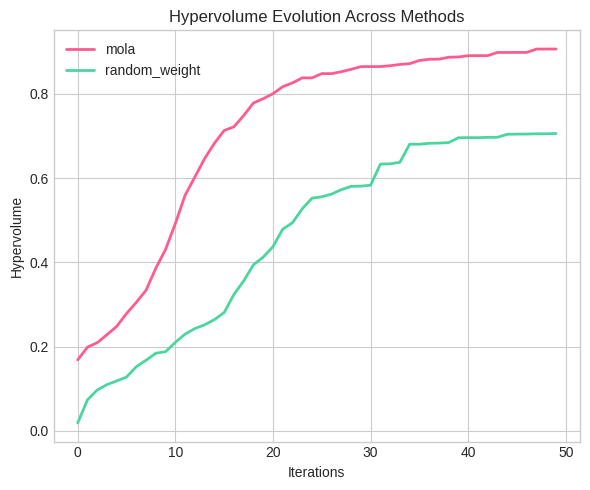

[Analyzer] Visualization complete.


In [ ]:
pareto_dict = {
        method: res["objectives"]
        for method, res in results.items()
        if "objectives" in res
    }

hypervolumes_dict = {
        method: res["hypervolume"]
        for method, res in results.items()
        if "hypervolume" in res
    }

axes_label = ["Bias", "Women"]
plot_pareto(methods=pareto_dict,
            labels=axes_label, 
            # title=title,
            fontsize=23,
            figsize=(10,7),
            save_path='images/2_objs_methods.pdf'
            )
plot_multiple_hypervolumes(methods_hv=hypervolumes_dict)

In [ ]:
from machinemoo.analysis.visualization import plot_pareto_set_limit

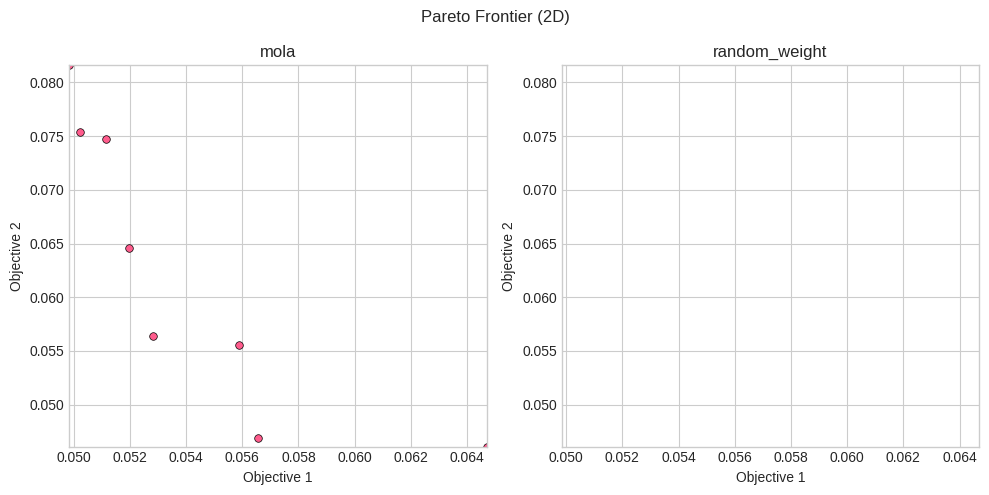

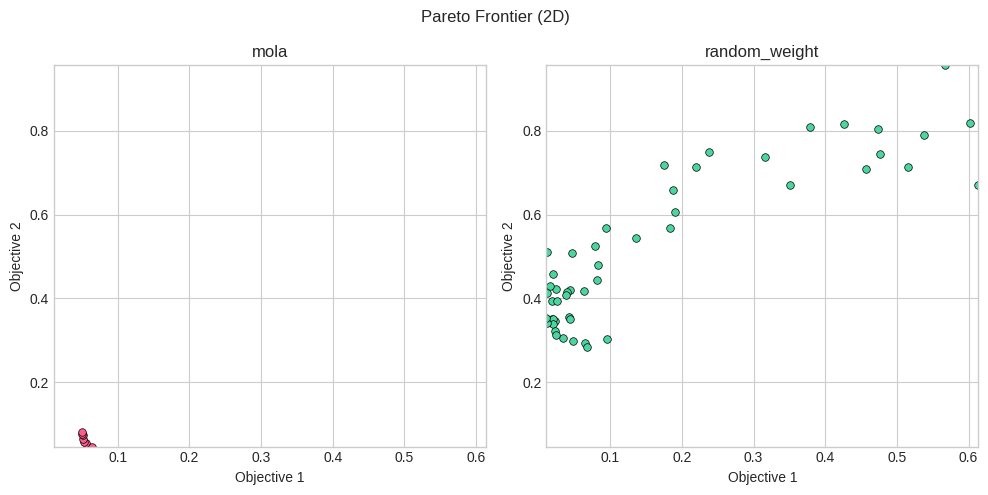

: 

In [ ]:
plot_pareto_set_limit(pareto_dict, axis_mode="first")
plot_pareto_set_limit(pareto_dict, axis_mode="global") 